Device: cuda

Generator:
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator:
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.33MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.89MB/s]



Dataset size: 60000

Starting Training...

Epoch [1/20] | D Loss: 0.2292 | G Loss: 3.3321
Epoch [2/20] | D Loss: 0.2311 | G Loss: 4.0653
Epoch [3/20] | D Loss: 0.2389 | G Loss: 4.9650
Epoch [4/20] | D Loss: 0.1274 | G Loss: 4.7854
Epoch [5/20] | D Loss: 0.2139 | G Loss: 3.4843
Epoch [6/20] | D Loss: 0.1921 | G Loss: 3.7212
Epoch [7/20] | D Loss: 1.1068 | G Loss: 18.8367
Epoch [8/20] | D Loss: 0.1047 | G Loss: 5.8089
Epoch [9/20] | D Loss: 0.3014 | G Loss: 4.1642
Epoch [10/20] | D Loss: 0.1012 | G Loss: 5.7388
Epoch [11/20] | D Loss: 0.0712 | G Loss: 5.3376
Epoch [12/20] | D Loss: 0.0008 | G Loss: 7.3805
Epoch [13/20] | D Loss: 0.0002 | G Loss: 8.3079
Epoch [14/20] | D Loss: 0.0005 | G Loss: 9.1902
Epoch [15/20] | D Loss: 0.0004 | G Loss: 9.3335
Epoch [16/20] | D Loss: 0.0125 | G Loss: 5.7602
Epoch [17/20] | D Loss: 0.0018 | G Loss: 6.5177
Epoch [18/20] | D Loss: 0.0004 | G Loss: 8.6679
Epoch [19/20] | D Loss: 0.0001 | G Loss: 9.3274
Epoch [20/20] | D Loss: 0.0003 | G Loss: 10.2594


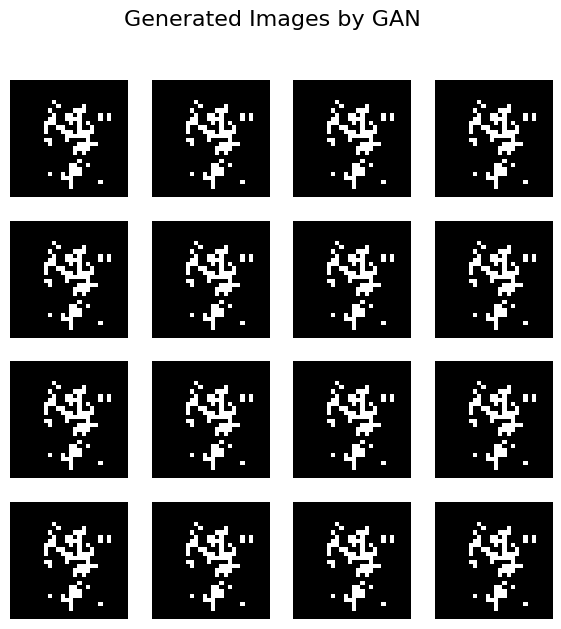

In [3]:
# ============================================
# COMPLETE VANILLA GAN - PyTorch + MNIST
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# ============================================
# 1. Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


# ============================================
# 2. Generator
# ============================================

class Generator(nn.Module):

    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(noise_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.ReLU(),

            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# ============================================
# 3. Discriminator
# ============================================

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# ============================================
# 4. Create Models
# ============================================

noise_dim = 100

G = Generator(noise_dim).to(device)
D = Discriminator().to(device)

print("\nGenerator:")
print(G)

print("\nDiscriminator:")
print(D)


# ============================================
# 5. Loss + Optimizers
# ============================================

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)


# ============================================
# 6. MNIST Dataset
# ============================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("\nDataset size:", len(dataset))


# ============================================
# 7. Training
# ============================================

epochs = 20

print("\nStarting Training...\n")

for epoch in range(epochs):

    for real_images, _ in loader:

        # -------------------------------
        # Prepare real images
        # -------------------------------

        real_images = real_images.view(-1, 784).to(device)

        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(
            batch_size, 1
        ).to(device)

        fake_labels = torch.zeros(
            batch_size, 1
        ).to(device)


        # ==================================
        # Train Discriminator
        # ==================================

        optimizer_D.zero_grad()


        # Real images
        real_output = D(real_images)

        loss_real = criterion(
            real_output,
            real_labels
        )


        # Generate fake images
        noise = torch.randn(
            batch_size,
            noise_dim
        ).to(device)

        fake_images = G(noise)


        # Discriminator evaluates fake images
        fake_output = D(fake_images.detach())

        loss_fake = criterion(
            fake_output,
            fake_labels
        )


        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()


        # ==================================
        # Train Generator
        # ==================================

        optimizer_G.zero_grad()


        noise = torch.randn(
            batch_size,
            noise_dim
        ).to(device)

        fake_images = G(noise)

        output = D(fake_images)


        # Generator wants fake images
        # to be classified as REAL

        loss_G = criterion(
            output,
            real_labels
        )


        loss_G.backward()

        optimizer_G.step()


    # ==================================
    # Print Loss
    # ==================================

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"| D Loss: {loss_D.item():.4f} "
        f"| G Loss: {loss_G.item():.4f}"
    )


# ============================================
# 8. Generate Images
# ============================================

G.eval()

noise = torch.randn(
    16,
    noise_dim
).to(device)

with torch.no_grad():

    generated = G(noise)


# Convert 784 -> 28x28

generated = generated.view(
    -1,
    1,
    28,
    28
)


# ============================================
# 9. Display Generated Images
# ============================================

fig, axes = plt.subplots(
    4,
    4,
    figsize=(7, 7)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        generated[i].cpu().squeeze(),
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle(
    "Generated Images by GAN",
    fontsize=16
)

plt.show()